# Project 2 — Yield-Curve Modelling with Machine Learning

**Goal.** Go beyond Nelson–Siegel: represent and forecast the US Treasury yield curve with
**autoencoders**, **Gaussian processes** and an **LSTM**, and compare them honestly against the
traditional factor models: the Dynamic Nelson–Siegel (Diebold–Li) model, PCA, and the benchmark
everyone forgets, the **random walk**.

**Data.** Daily constant-maturity Treasury (CMT) par yields from FRED (H.15), 3 months to 20 years,
1994 – Sep 2026 (cached in `data_cache/`). The 30y tenor is dropped because the Treasury stopped issuing
it in 2002–2006, and 1m because it starts only in 2001.

| § | Content |
|---|---|
| 1 | The data and the three stylised facts (level / slope / curvature) |
| 2 | Representation: Nelson–Siegel vs PCA vs a nonlinear autoencoder |
| 3 | Gaussian processes across maturity: curve fitting with uncertainty |
| 4 | Forecasting set-up: rolling-origin, annual re-fit, 2012–2026 out-of-sample |
| 5 | Models: RW, DNS-AR, PCA-VAR, AE-latent, GP, LSTM |
| 6 | Results: RMSE by tenor/horizon, Diebold–Mariano tests, errors through time |
| 7 | Strengths, weaknesses, extensions |

In [1]:
import warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C, Matern

from IPython.display import display
from qdata import fred_rates

warnings.filterwarnings("ignore")
torch.set_num_threads(4)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

TENORS = {"DGS3MO": 3, "DGS6MO": 6, "DGS1": 12, "DGS2": 24, "DGS3": 36, "DGS5": 60,
          "DGS7": 84, "DGS10": 120, "DGS20": 240}
fr = fred_rates()
Y = fr[list(TENORS)].loc["1994-01-01":].dropna()
Y.columns = [f"{m//12}y" if m >= 12 else f"{m}m" for m in TENORS.values()]
TAU = np.array(list(TENORS.values()), dtype=float)          # maturities in months
print(f"{len(Y):,} daily curves, {Y.index[0].date()} → {Y.index[-1].date()}")
Y.tail(3)

8,188 daily curves, 1994-01-03 → 2026-09-24


,3m,6m,1y,2y,3y,5y,7y,10y,20y
date,,,,,,,,,
2026-09-22,4.160,4.260,4.430,4.710,4.810,4.830,4.890,4.960,5.330
2026-09-23,4.190,4.310,4.490,4.850,4.970,4.990,5.050,5.110,5.450
2026-09-24,4.240,4.340,4.510,4.870,4.990,5.030,5.100,5.180,5.530


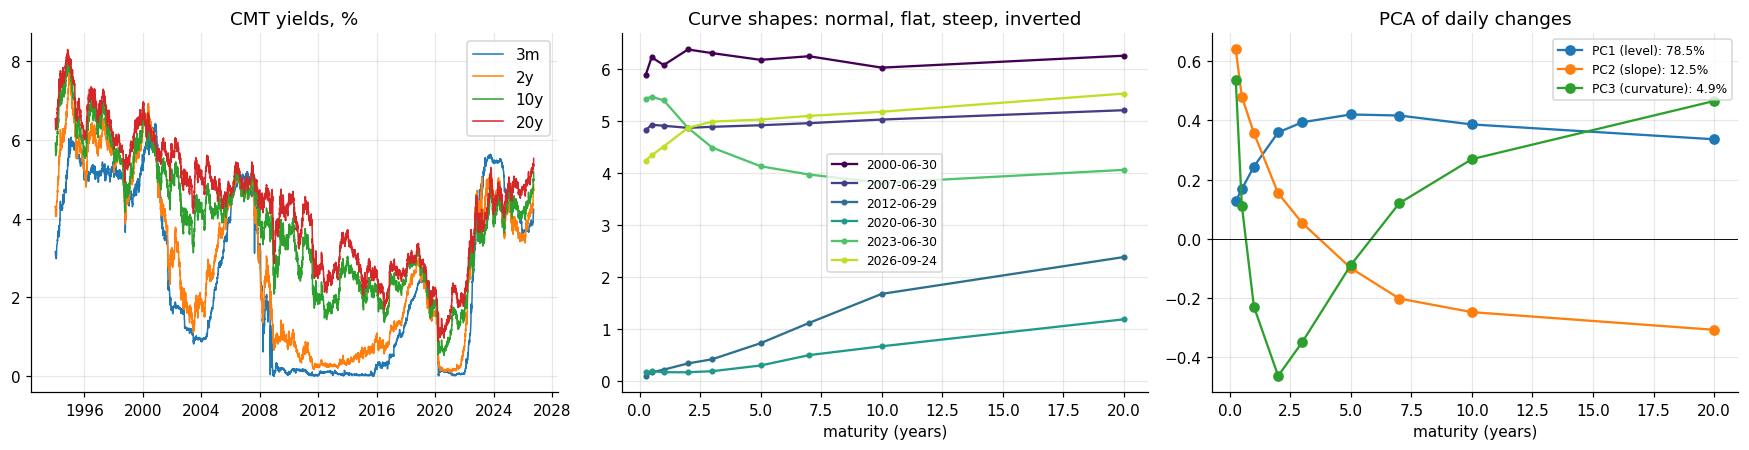

In [2]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.2))
for c in ["3m", "2y", "10y", "20y"]:
    axs[0].plot(Y.index, Y[c], lw=1, label=c)
axs[0].set_title("CMT yields, %"); axs[0].legend()
for d, col in zip(["2000-06-30", "2007-06-29", "2012-06-29", "2020-06-30", "2023-06-30", str(Y.index[-1].date())],
                  plt.cm.viridis(np.linspace(0, .9, 6))):
    i = Y.index.get_indexer([pd.Timestamp(d)], method="nearest")[0]
    axs[1].plot(TAU / 12, Y.iloc[i], "o-", ms=3, color=col, label=str(Y.index[i].date()))
axs[1].set_xlabel("maturity (years)"); axs[1].set_title("Curve shapes: normal, flat, steep, inverted"); axs[1].legend(fontsize=8)
pca_all = PCA(3).fit(Y.diff().dropna())
for j, lab in enumerate(["PC1 (level)", "PC2 (slope)", "PC3 (curvature)"]):
    axs[2].plot(TAU / 12, pca_all.components_[j], "o-", label=f"{lab}: {pca_all.explained_variance_ratio_[j]:.1%}")
axs[2].axhline(0, color="k", lw=.6); axs[2].set_xlabel("maturity (years)")
axs[2].set_title("PCA of daily changes"); axs[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 1. Stylised facts
The classic Litterman–Scheinkman (1991) result shows up immediately: three principal components explain
~99 % of daily curve changes, and they have an economic reading: **level** (parallel shift), **slope**
(short vs long end), and **curvature** (belly vs wings). Every model below is, one way or another, a
low-dimensional description of these three movements.

## 2. Representation: Nelson–Siegel, PCA and an autoencoder

### 2.1 Nelson–Siegel (1987) / Diebold–Li (2006)
$$y(\tau)=\beta_1+\beta_2\,\frac{1-e^{-\lambda\tau}}{\lambda\tau}+\beta_3\Big(\frac{1-e^{-\lambda\tau}}{\lambda\tau}-e^{-\lambda\tau}\Big)$$
With $\lambda$ fixed (Diebold–Li: $\lambda=0.0609$ per month, which puts the curvature loading's peak at 30
months), the betas come from a daily cross-sectional OLS, and they *are* level, slope and curvature.
The loadings are fixed smooth functions, so NS is parsimonious, interpretable and can interpolate any
maturity, but it's also rigid.

### 2.2 PCA
The data-driven linear alternative: the loadings are whatever directions carry the most variance.
It's optimal among *linear* 3-factor representations, in-sample.

### 2.3 Autoencoder
A neural network $\text{decoder}(\text{encoder}(y))\approx y$ with a 3-unit bottleneck. With linear
activations it recovers PCA. With nonlinear ones it can in principle bend the factor surface (e.g. the
curve behaves differently near the zero lower bound). We train on 1994–2011 and measure reconstruction
error on 2012–2026 **out of sample**, which is the fair test for any representation.

In [3]:
LAM = 0.0609
def ns_loadings(tau, lam=LAM):
    x = lam * tau
    l2 = (1 - np.exp(-x)) / x
    return np.column_stack([np.ones_like(tau), l2, l2 - np.exp(-x)])

L_NS = ns_loadings(TAU)
BETA = pd.DataFrame(np.linalg.lstsq(L_NS, Y.T.values, rcond=None)[0].T, index=Y.index,
                    columns=["level", "slope", "curvature"])

SPLIT = pd.Timestamp("2012-01-01")
tr, te = Y[Y.index < SPLIT], Y[Y.index >= SPLIT]
mu, sd = tr.mean(), tr.std()


class AE(nn.Module):
    def __init__(self, n=9, k=3, h=32):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(n, h), nn.Tanh(), nn.Linear(h, k))
        self.dec = nn.Sequential(nn.Linear(k, h), nn.Tanh(), nn.Linear(h, n))
    def forward(self, x):
        return self.dec(self.enc(x))


def train_ae(X, k=3, epochs=400, seed=0, lr=3e-3):
    torch.manual_seed(seed)
    m = AE(X.shape[1], k)
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    Xt = torch.tensor(X, dtype=torch.float32)
    for ep in range(epochs):
        perm = torch.randperm(len(Xt))
        for i in range(0, len(Xt), 256):
            b = Xt[perm[i:i + 256]]
            loss = ((m(b) - b) ** 2).mean()
            opt.zero_grad(); loss.backward(); opt.step()
    return m.eval()


t0 = time.time()
ae = train_ae(((tr - mu) / sd).values)
with torch.no_grad():
    rec_ae = ae(torch.tensor(((te - mu) / sd).values, dtype=torch.float32)).numpy() * sd.values + mu.values
pca3 = PCA(3).fit(tr.values)
rec_pca = pca3.inverse_transform(pca3.transform(te.values))
rec_ns = (np.linalg.lstsq(L_NS, te.T.values, rcond=None)[0].T) @ L_NS.T
print(f"AE trained in {time.time()-t0:.0f}s")

rec = pd.DataFrame({
    "Nelson–Siegel (3 fixed-shape factors)": np.sqrt(((rec_ns - te.values) ** 2).mean(0)) * 100,
    "PCA (3, loadings from 1994–2011)": np.sqrt(((rec_pca - te.values) ** 2).mean(0)) * 100,
    "Autoencoder (3-d bottleneck)": np.sqrt(((rec_ae - te.values) ** 2).mean(0)) * 100}, index=Y.columns).T
rec["average"] = rec.mean(1)
print("Out-of-sample (2012–2026) reconstruction RMSE, basis points")
rec

AE trained in 4s
Out-of-sample (2012–2026) reconstruction RMSE, basis points


,3m,6m,1y,2y,3y,5y,7y,10y,20y,average
Nelson–Siegel (3 fixed-shape factors),9.951,4.342,10.319,7.961,2.949,10.410,9.307,7.418,15.008,8.630
"PCA (3, loadings from 1994–2011)",10.575,7.777,8.556,5.811,3.695,8.796,8.969,4.802,11.462,7.827
Autoencoder (3-d bottleneck),17.783,7.709,7.898,12.553,8.648,8.341,11.085,17.846,16.867,12.081


**Reading.** All three compress a 9-dimensional curve into 3 numbers with average errors below ~12 bp, but the ranking
is instructive:
* **PCA is best on average**, and NS is close behind: its fixed shapes cost it mostly at the 20y point and the short end.
* **The autoencoder is the worst out of sample**, even though a nonlinear network nests PCA in principle. It was trained on
  1994–2011, a period with no zero-lower-bound decade and no 2022–23 inversion, and its nonlinear decoder *extrapolates badly* to
  regimes it never saw (look at its 3m and 10y errors). A linear map extrapolates gracefully; a tanh network saturates.
* The lesson generalises: flexibility helps in-sample, but a learnt representation is only as good as the range of its training
  data. NS's rigidity is also robustness.

## 3. Gaussian processes across maturity
A GP is a prior over functions $y(\tau)\sim\mathcal{GP}(m(\tau),k(\tau,\tau'))$. Conditioning on the 9
observed yields gives a posterior mean curve **and** a credible band at every maturity. It is a
non-parametric alternative to NS for curve fitting and interpolation. We use a Matérn-5/2 kernel on
$\log\tau$ plus white noise (quotes have noise), with the prior mean set to the NS fit, so the GP
learns only the *residual* shape.

**Test:** leave one tenor out, fit on the other 8, predict the missing one. This measures honest
interpolation skill, which is what a curve builder is for.

In [4]:
def gp_curve(tau, y, tau_new, prior_mean=True):
    x, xn = np.log(tau)[:, None], np.log(tau_new)[:, None]
    if prior_mean:
        b = np.linalg.lstsq(ns_loadings(tau), y, rcond=None)[0]
        m, mn = ns_loadings(tau) @ b, ns_loadings(tau_new) @ b
    else:
        m, mn = np.full(len(tau), y.mean()), np.full(len(tau_new), y.mean())
    k = C(0.05, (1e-4, 10)) * Matern(length_scale=1.0, length_scale_bounds=(0.2, 5), nu=2.5) + \
        WhiteKernel(1e-4, (1e-7, 1e-2))
    gp = GaussianProcessRegressor(k, normalize_y=False, n_restarts_optimizer=2, random_state=0).fit(x, y - m)
    mu_, sd_ = gp.predict(xn, return_std=True)
    return mu_ + mn, sd_


rng = np.random.default_rng(0)
days = Y.index[rng.choice(len(Y), 250, replace=False)]
loo = []
for d in days:
    y = Y.loc[d].values
    for j in range(1, len(TAU) - 1):                           # interior tenors only (no extrapolation)
        keep = np.arange(len(TAU)) != j
        g, _ = gp_curve(TAU[keep], y[keep], TAU[[j]])
        b = np.linalg.lstsq(ns_loadings(TAU[keep]), y[keep], rcond=None)[0]
        lin = np.interp(np.log(TAU[j]), np.log(TAU[keep]), y[keep])
        loo.append(dict(tenor=Y.columns[j], GP=(g[0] - y[j]) * 100, NS=(ns_loadings(TAU[[j]]) @ b)[0] * 100 - y[j] * 100,
                        linear=(lin - y[j]) * 100))
loo = pd.DataFrame(loo)
print("Leave-one-tenor-out interpolation RMSE (bp), 250 random days")
loo.groupby("tenor", sort=False)[["linear", "NS", "GP"]].apply(lambda d: np.sqrt((d ** 2).mean())).T

Leave-one-tenor-out interpolation RMSE (bp), 250 random days


tenor,6m,1y,2y,3y,5y,7y,10y
linear,7.347,10.141,7.568,7.759,5.999,5.877,9.152
NS,8.332,13.162,11.080,4.981,11.777,10.494,12.097
GP,7.243,9.544,6.941,3.697,5.879,4.578,9.850


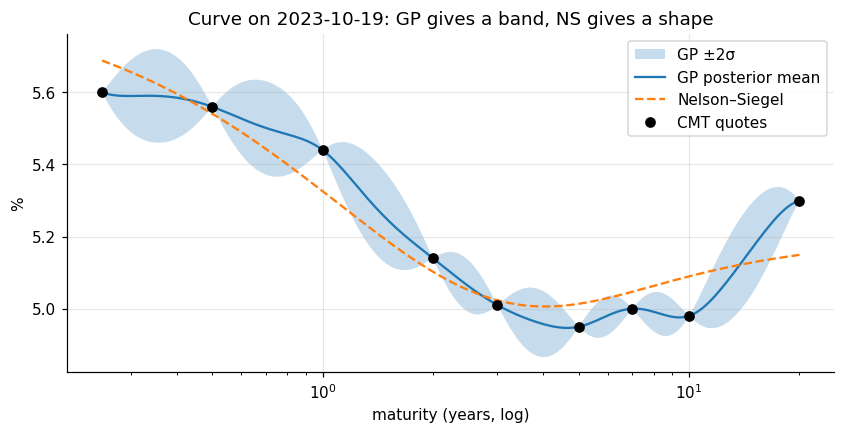

In [5]:
d = pd.Timestamp("2023-10-19")                          # a strongly humped / inverted curve
i = Y.index.get_indexer([d], method="nearest")[0]; d = Y.index[i]
y = Y.iloc[i].values
tt = np.geomspace(3, 240, 200)
g, s = gp_curve(TAU, y, tt)
b = np.linalg.lstsq(L_NS, y, rcond=None)[0]
fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(tt / 12, g - 2 * s, g + 2 * s, alpha=.25, label="GP ±2σ")
ax.plot(tt / 12, g, label="GP posterior mean"); ax.plot(tt / 12, ns_loadings(tt) @ b, "--", label="Nelson–Siegel")
ax.plot(TAU / 12, y, "ko", label="CMT quotes")
ax.set_xscale("log"); ax.set_xlabel("maturity (years, log)"); ax.set_ylabel("%"); ax.legend()
ax.set_title(f"Curve on {d.date()}: GP gives a band, NS gives a shape"); plt.show()

The GP has the lowest leave-one-out error at most tenors: it keeps NS's global shape as its prior mean, then bends to fit local
features. NS alone is the worst interpolator, because one hump shape can't pass through all the quotes. Plain linear
interpolation (in log-maturity) is a surprisingly strong baseline, and it beats NS everywhere except 3y. The GP's real extra
value is the **uncertainty band**: it tells you *where* the curve is poorly pinned down (between widely spaced quotes and at the long end).

## 4. Forecasting set-up
**Target.** The yield change over the next $h$ trading days, $\Delta y_{t+h}=y_{t+h}-y_t$, for all 9 tenors,
at $h=21$ (≈1 month) and $h=63$ (≈1 quarter).

**Protocol (no look-ahead).** For each test year 2012–2026 we re-fit every model on data **strictly before**
that year, where the training pairs $(t,t+h)$ must have $t+h$ inside the training window. We then forecast
from every trading day of the test year. This is an expanding-window, annually re-fitted, out-of-sample test.

**The benchmark.** The random walk says $\hat y_{t+h}=y_t$. For horizons up to a few months it is famously hard
to beat (Duffee 2002; Diebold–Li 2006 beat it mainly at 6–12 months). Beating it is the real test.

In [6]:
H_LIST = [21, 63]
YEARS = list(range(2012, Y.index[-1].year + 1))
Yv = Y.values
dates = Y.index


def direct_pairs(F, idx_end, h):
    """X_t, target F_{t+h} for all t with t+h < idx_end (both are row positions)."""
    t = np.arange(0, idx_end - h)
    return t, t + h


class Forecaster:
    name = "base"
    def fit(self, end, h): ...
    def predict(self, idx, h): ...               # returns predicted y_{t+h} for rows idx


class RW(Forecaster):
    name = "Random walk"
    def fit(self, end, h): pass
    def predict(self, idx, h): return Yv[idx]


class DNS(Forecaster):
    """Diebold–Li: NS betas with fixed lambda, each beta follows an AR(1) — fitted *directly* at horizon h."""
    name = "DNS-AR(1)"
    def fit(self, end, h):
        B = BETA.values
        t, th = direct_pairs(B, end, h)
        self.coef = [np.polyfit(B[t, j], B[th, j], 1) for j in range(3)]
    def predict(self, idx, h):
        B = BETA.values[idx]
        Bh = np.column_stack([np.polyval(self.coef[j], B[:, j]) for j in range(3)])
        return Bh @ L_NS.T


class PCAVAR(Forecaster):
    """3 PCs of yield levels (fit in-window), direct VAR(1) at horizon h, map back."""
    name = "PCA-VAR(1)"
    def fit(self, end, h):
        self.p = PCA(3).fit(Yv[:end])
        Z = self.p.transform(Yv[:end])
        t, th = direct_pairs(Z, end, h)
        X = np.column_stack([np.ones(len(t)), Z[t]])
        self.A = np.linalg.lstsq(X, Z[th], rcond=None)[0]
    def predict(self, idx, h):
        Z = self.p.transform(Yv[idx])
        return self.p.inverse_transform(np.column_stack([np.ones(len(idx)), Z]) @ self.A)


class AELatent(Forecaster):
    """Nonlinear AE compresses the curve; a direct linear model forecasts the latent; the decoder maps back."""
    name = "Autoencoder-latent"
    def fit(self, end, h):
        self.mu, self.sd = Yv[:end].mean(0), Yv[:end].std(0)
        self.ae = train_ae((Yv[:end] - self.mu) / self.sd, epochs=150)
        with torch.no_grad():
            Z = self.ae.enc(torch.tensor((Yv[:end] - self.mu) / self.sd, dtype=torch.float32)).numpy()
        t, th = direct_pairs(Z, end, h)
        self.A = np.linalg.lstsq(np.column_stack([np.ones(len(t)), Z[t]]), Z[th], rcond=None)[0]
    def predict(self, idx, h):
        with torch.no_grad():
            Z = self.ae.enc(torch.tensor((Yv[idx] - self.mu) / self.sd, dtype=torch.float32)).numpy()
            Zh = np.column_stack([np.ones(len(idx)), Z]) @ self.A
            return self.ae.dec(torch.tensor(Zh, dtype=torch.float32)).numpy() * self.sd + self.mu


def factor_features(idx):
    """Current NS betas + their 1m and 3m changes: the state a forecaster conditions on."""
    B = BETA.values
    i21, i63 = np.maximum(idx - 21, 0), np.maximum(idx - 63, 0)
    return np.column_stack([B[idx], B[idx] - B[i21], B[idx] - B[i63]])


class GPFactor(Forecaster):
    """GP regression of the h-day change in each NS beta on the factor state (sub-sampled for O(n^3))."""
    name = "GP on NS factors"
    def fit(self, end, h):
        t, th = direct_pairs(None, end, h)
        t = t[t >= 63]; th = t + h
        sub = t[:: max(1, len(t) // 1200)]                     # ~1200 points
        X = factor_features(sub); self.xm, self.xs = X.mean(0), X.std(0)
        dB = BETA.values[sub + h] - BETA.values[sub]
        k = C(1.0) * RBF(length_scale=np.ones(X.shape[1]) * 2, length_scale_bounds=(0.1, 100)) + WhiteKernel(0.5)
        self.gps = [GaussianProcessRegressor(k, normalize_y=True, random_state=0).fit((X - self.xm) / self.xs, dB[:, j])
                    for j in range(3)]
    def predict(self, idx, h):
        X = (factor_features(idx) - self.xm) / self.xs
        dB = np.column_stack([g.predict(X) for g in self.gps])
        return (BETA.values[idx] + dB) @ L_NS.T


class LSTMNet(nn.Module):
    def __init__(self, n_in=9, hid=32, n_out=9):
        super().__init__()
        self.lstm = nn.LSTM(n_in, hid, batch_first=True)
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(hid, n_out))
    def forward(self, x):
        o, _ = self.lstm(x)
        return self.head(o[:, -1])


class LSTMFc(Forecaster):
    """Sequence of the last 21 days of (standardised) curves -> h-day change of all tenors.
    Early stopping on the last 15 % of the training window; an ensemble of 2 seeds."""
    name = "LSTM"
    SEQ = 21
    def _seq(self, idx):
        X = (Yv - self.mu) / self.sd
        return np.stack([X[i - self.SEQ + 1:i + 1] for i in idx]).astype(np.float32)
    def fit(self, end, h):
        self.mu, self.sd = Yv[:end].mean(0), Yv[:end].std(0)
        t = np.arange(self.SEQ, end - h)
        dy = (Yv[t + h] - Yv[t]); self.ds = dy.std(0)
        Xs, Ys = torch.tensor(self._seq(t)), torch.tensor((dy / self.ds).astype(np.float32))
        n_val = int(len(t) * 0.15)
        # purge h days between train and validation so overlapping targets don't leak
        Xtr, Ytr, Xva, Yva = Xs[:-n_val - h], Ys[:-n_val - h], Xs[-n_val:], Ys[-n_val:]
        self.models = []
        for seed in range(2):
            torch.manual_seed(seed)
            m = LSTMNet(); opt = torch.optim.Adam(m.parameters(), lr=2e-3, weight_decay=1e-4)
            best, best_state, bad = np.inf, None, 0
            for ep in range(25):
                m.train(); perm = torch.randperm(len(Xtr))
                for i in range(0, len(Xtr), 256):
                    b = perm[i:i + 256]
                    loss = ((m(Xtr[b]) - Ytr[b]) ** 2).mean()
                    opt.zero_grad(); loss.backward(); opt.step()
                m.eval()
                with torch.no_grad():
                    v = ((m(Xva) - Yva) ** 2).mean().item()
                if v < best - 1e-4:
                    best, best_state, bad = v, {k: x.clone() for k, x in m.state_dict().items()}, 0
                else:
                    bad += 1
                    if bad >= 4: break
            m.load_state_dict(best_state); self.models.append(m.eval())
    def predict(self, idx, h):
        X = torch.tensor(self._seq(idx))
        with torch.no_grad():
            dy = np.mean([m(X).numpy() for m in self.models], axis=0) * self.ds
        return Yv[idx] + dy


MODELS = [RW, DNS, PCAVAR, AELatent, GPFactor, LSTMFc]

## 5. Running the out-of-sample experiment
6 models × 2 horizons × 15 annual re-fits. The LSTM (2 seeds, early stopping) and the GP dominate the run time (≈15–20 min in total on a laptop CPU).

In [7]:
t0 = time.time()
records = []
for h in H_LIST:
    for yr in YEARS:
        start = np.searchsorted(dates, pd.Timestamp(f"{yr}-01-01"))
        stop = np.searchsorted(dates, pd.Timestamp(f"{yr+1}-01-01"))
        idx = np.arange(start, min(stop, len(dates) - h))           # origins whose target is observed
        if len(idx) == 0:
            continue
        for M in MODELS:
            m = M(); m.fit(start, h)
            pred = m.predict(idx, h)
            err = (pred - Yv[idx + h]) * 100                        # bp
            for j, ten in enumerate(Y.columns):
                records.append(pd.DataFrame({"h": h, "model": M.name, "tenor": ten, "date": dates[idx],
                                             "err": err[:, j], "dy": (Yv[idx + h, j] - Yv[idx, j]) * 100,
                                             "pred_dy": (pred[:, j] - Yv[idx, j]) * 100}))
    print(f"h={h}: done in {time.time()-t0:.0f}s")
res = pd.concat(records, ignore_index=True)

h=21: done in 444s


h=63: done in 898s


## 6. Results
### 6.1 RMSE and the ratio to the random walk

In [8]:
rmse = res.groupby(["h", "model", "tenor"], sort=False).err.apply(lambda e: np.sqrt((e ** 2).mean())).unstack("tenor")
for h in H_LIST:
    r = rmse.loc[h]
    ratio = r / r.loc["Random walk"]
    print(f"\n=== h = {h} trading days: RMSE (bp), and ratio to random walk (<1 = better) ===")
    display(r.assign(avg=r.mean(1)).round(1))
    display(ratio.assign(avg=ratio.mean(1)).style.format("{:.3f}").background_gradient(cmap="RdYlGn_r", vmin=0.85, vmax=1.15))


=== h = 21 trading days: RMSE (bp), and ratio to random walk (<1 = better) ===


tenor,3m,6m,1y,2y,3y,5y,7y,10y,20y,avg
model,,,,,,,,,,
Random walk,18.000,18.200,19.300,21.500,22.500,23.400,23.500,22.700,21.900,21.200
DNS-AR(1),18.300,20.900,23.400,23.300,23.200,25.200,24.400,22.900,28.100,23.300
PCA-VAR(1),16.600,19.600,22.200,22.700,23.200,24.000,23.500,22.500,25.800,22.200
Autoencoder-latent,17.800,18.800,23.400,24.300,23.400,23.900,23.700,23.300,24.700,22.600
GP on NS factors,19.600,23.000,26.000,26.200,25.100,25.900,25.300,24.500,31.300,25.200
LSTM,18.300,18.600,19.800,21.700,22.600,23.600,23.800,22.800,22.100,21.500


tenor,3m,6m,1y,2y,3y,5y,7y,10y,20y,avg
model,,,,,,,,,,
Random walk,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
DNS-AR(1),1.019,1.149,1.215,1.086,1.032,1.079,1.042,1.009,1.279,1.101
PCA-VAR(1),0.923,1.075,1.152,1.058,1.030,1.027,1.004,0.993,1.176,1.049
Autoencoder-latent,0.990,1.031,1.212,1.130,1.042,1.020,1.011,1.027,1.128,1.066
GP on NS factors,1.092,1.260,1.350,1.220,1.115,1.107,1.079,1.082,1.425,1.192
LSTM,1.018,1.018,1.026,1.009,1.008,1.007,1.013,1.006,1.008,1.013



=== h = 63 trading days: RMSE (bp), and ratio to random walk (<1 = better) ===


tenor,3m,6m,1y,2y,3y,5y,7y,10y,20y,avg
model,,,,,,,,,,
Random walk,42.400,42.200,42.200,43.000,42.800,42.100,41.800,40.600,39.000,41.800
DNS-AR(1),42.700,47.300,47.700,45.900,44.800,43.800,42.300,40.100,44.700,44.400
PCA-VAR(1),39.300,42.300,44.200,44.600,44.800,43.900,42.500,40.400,43.500,42.800
Autoencoder-latent,38.000,40.800,44.700,45.900,45.300,44.600,43.300,41.200,42.600,42.900
GP on NS factors,46.400,51.100,51.900,50.400,47.300,43.900,42.900,42.200,49.900,47.300
LSTM,46.800,46.000,46.700,45.800,45.300,43.900,43.300,41.500,39.400,44.300


tenor,3m,6m,1y,2y,3y,5y,7y,10y,20y,avg
model,,,,,,,,,,
Random walk,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
DNS-AR(1),1.007,1.119,1.131,1.067,1.045,1.039,1.014,0.987,1.148,1.062
PCA-VAR(1),0.928,1.003,1.048,1.037,1.046,1.042,1.016,0.994,1.116,1.026
Autoencoder-latent,0.898,0.965,1.060,1.067,1.057,1.059,1.037,1.014,1.094,1.028
GP on NS factors,1.095,1.211,1.230,1.171,1.104,1.042,1.026,1.040,1.281,1.133
LSTM,1.105,1.091,1.106,1.065,1.058,1.042,1.038,1.022,1.010,1.060


### 6.2 Is any improvement statistically significant? Diebold–Mariano tests
$d_t = e^2_{model,t}-e^2_{RW,t}$. The forecasts overlap ($h$-day targets observed daily), so $d_t$ is strongly
autocorrelated. We use a Newey–West HAC standard error with $h$ lags. $t<-2$ means the model beats the random walk.

In [9]:
def dm_stat(e_m, e_rw, h):
    d = e_m ** 2 - e_rw ** 2
    r = sm.OLS(d, np.ones(len(d))).fit(cov_type="HAC", cov_kwds={"maxlags": h})
    return r.tvalues[0]

rows = []
for h in H_LIST:
    for m in [M.name for M in MODELS[1:]]:
        row = {"h": h, "model": m}
        for ten in ["3m", "2y", "10y", "20y"]:
            a = res[(res.h == h) & (res.model == m) & (res.tenor == ten)].err.values
            b = res[(res.h == h) & (res.model == "Random walk") & (res.tenor == ten)].err.values
            row[ten] = dm_stat(a, b, h)
        rows.append(row)
dm = pd.DataFrame(rows).set_index(["h", "model"])
print("Diebold–Mariano t-statistics vs random walk (negative = model better)")
dm.style.format("{:.2f}").background_gradient(cmap="RdYlGn_r", vmin=-3, vmax=3)

Diebold–Mariano t-statistics vs random walk (negative = model better)


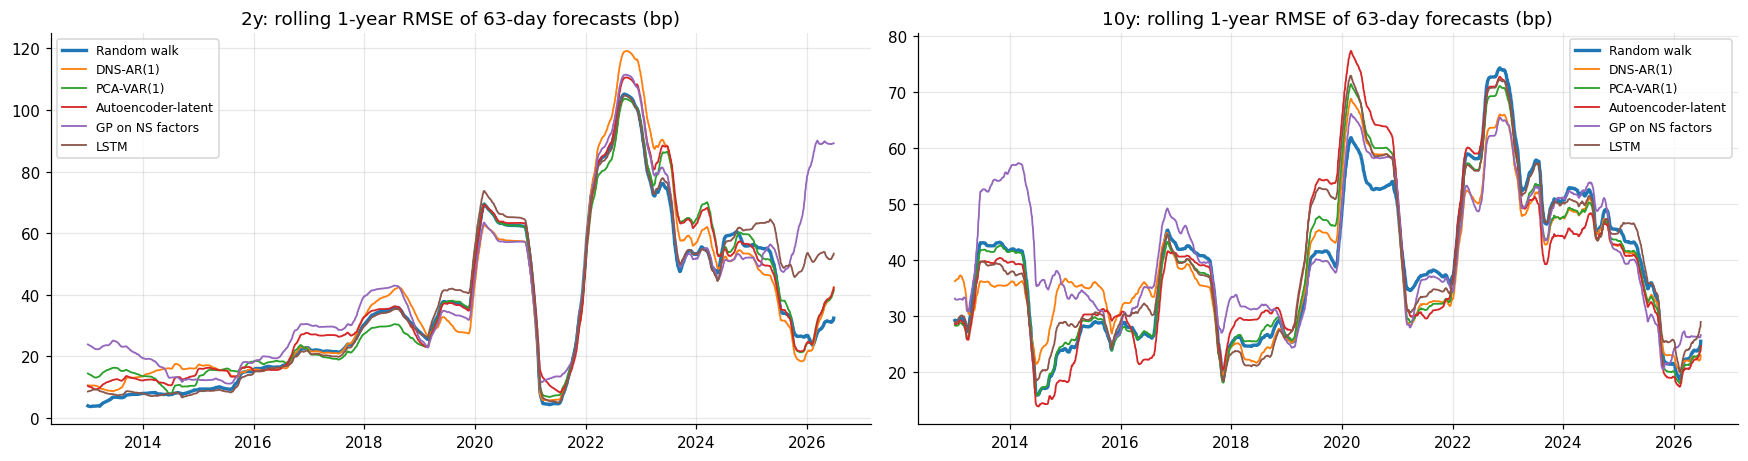

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4.3))
for ax, ten in zip(axs, ["2y", "10y"]):
    for m, c in zip([M.name for M in MODELS], plt.cm.tab10.colors):
        e = res[(res.h == 63) & (res.model == m) & (res.tenor == ten)].set_index("date").err
        ax.plot(e.pow(2).rolling(252).mean().pow(.5), color=c, lw=1.2 if m != "Random walk" else 2.2, label=m)
    ax.set_title(f"{ten}: rolling 1-year RMSE of 63-day forecasts (bp)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [11]:
hit = res[res.model != "Random walk"].groupby(["h", "model"]).apply(
    lambda d: pd.Series({"direction hit-rate": np.mean(np.sign(d.pred_dy) == np.sign(d.dy)),
                         "corr(pred Δy, realised Δy)": np.corrcoef(d.pred_dy, d.dy)[0, 1]}))
hit.unstack(0).round(3)

direction hit-rate       corr(pred Δy, realised Δy)       
h                                  21    63                         21     63
model                                                                        
Autoencoder-latent              0.507 0.519                      0.092  0.173
DNS-AR(1)                       0.486 0.511                      0.001 -0.020
GP on NS factors                0.482 0.514                      0.013  0.106
LSTM                            0.462 0.454                     -0.011  0.037
PCA-VAR(1)                      0.515 0.539                      0.101  0.170

### 6.3 What the results say
* **Nothing beats the random walk in a statistically meaningful way.** On average across tenors every model's RMSE ratio is ≥ 1 at both
  horizons. The only ratios below 1 are at the 3-month tenor (PCA-VAR ≈ 0.92, autoencoder ≈ 0.90 at one quarter), where the Fed's path is
  partly predictable from the curve's slope, and their DM statistics are insignificant. Several models are significantly *worse* than the
  random walk (DM t > 2), mostly at 2y and 20y.
* **Regimes dominate everything.** The rolling-RMSE chart shows every model's error, random walk included, roughly tripling in 2022, when the Fed
  hiked by 425 bp. The mean-reverting factor models (DNS-AR, PCA-VAR) do *somewhat* worse than the random walk at the peak (2y: DNS ≈ 120 bp vs
  RW ≈ 105 bp), because they kept pulling yields back toward a training-sample mean the market was leaving behind. The GP degrades badly at the 2y
  point again in 2025–26.
* **The LSTM learns to be a random walk.** Its RMSE ratio is ≈ 1.01 at one month: early stopping pushes it toward predicting almost no change,
  the safest forecast. At one quarter it's somewhat worse than RW. The GP is the worst forecaster. With few effective samples (overlapping
  targets, a handful of rate cycles), its flexible mean function fits noise.
* **Weak but real signal.** PCA-VAR and the autoencoder's predicted changes correlate ≈ 0.1–0.17 with realised changes and get the direction right
  51–54 % of the time: a little information, far too little to overcome the noise in RMSE terms.
* ML adds **flexibility, not information**. Every model here sees only the past curve. Where the literature does find gains is by adding
  *information*: macro data, Fed-funds/SOFR futures, supply, option-implied rate vol (e.g. Ludvigson–Ng 2009; Bianchi–Büchner–Tamoni 2021), or by
  forecasting excess bond returns at 1-year horizons instead of yield changes at 1–3 months.

## 7. Strengths, weaknesses and extensions
| Model | Strengths | Weaknesses |
|---|---|---|
| Random walk | zero parameters, unbiased at short horizons, the benchmark | no economics, no term-premium information |
| Nelson–Siegel / DNS | interpretable, smooth, any maturity, robust to regime | rigid shapes; not arbitrage-free (AFNS fixes this); AR(1) mean-reverts to the sample mean |
| PCA-VAR | optimal linear compression, trivial to fit | loadings are sample-specific; same mean-reversion issue |
| Autoencoder | nonlinear compression, can capture ZLB-type bends | needs representative training data, extrapolates poorly to new regimes, less interpretable |
| Gaussian process | calibrated uncertainty bands, excellent interpolation | $O(n^3)$, so forecasting needs sub-sampling; kernel choice matters; the uncertainty is only as good as the kernel |
| LSTM | can use long histories and many inputs | data-hungry, unstable across seeds, overfits few rate cycles |

**Caveats in this implementation.** CMT par yields are used directly, not zero rates, which is fine for
forecasting and compression but not for pricing. λ is fixed at the Diebold–Li value. The LSTM hyper-parameters
weren't tuned (tuning on the test years would be look-ahead). Overlapping targets inflate apparent sample size,
which is why DM tests use HAC errors.

**Extensions.** Arbitrage-free Nelson–Siegel (Christensen–Diebold–Rudebusch 2011); add macro factors or SOFR/Fed-funds
futures (see Databento `SR3`, `ZQ` in `market_data/Databento`) as LSTM inputs; forecast *excess bond returns* instead
of yields; a Treasury-futures trading back-test on the forecasts (ZT/ZF/ZN/ZB).

**References.** Nelson & Siegel (1987); Litterman & Scheinkman (1991); Diebold & Li, *J. Econometrics* (2006);
Duffee (2002); Rasmussen & Williams, *Gaussian Processes for ML* (2006); Bianchi, Büchner & Tamoni, "Bond risk premiums
with machine learning", *RFS* (2021).